In [3]:
import pandas as pd
import numpy as np
import gpxpy
from geopy.distance import geodesic
from pathlib import Path
from tqdm import tqdm
import osmnx as ox
import networkx as nx
from fitparse import FitFile
import pickle
from IPython.display import display
import folium
import plotly.express as px
import random
import gpxpy.gpx
from collections import defaultdict
import matplotlib.pyplot as plt
from collections import Counter
import math
import requests
import time

In [2]:
with open('data/dataset_points.pkl', 'rb') as f:
    dataset_points = pickle.load(f)
print('Type:', type(dataset_points))

try:
    display(dataset_points.head())
except Exception:
    import pandas as pd
    try:
        df = pd.DataFrame(dataset_points)
        display(df.head())
    except Exception as e:
        print('Impossible de convertir en DataFrame:', e)
        print('Aperçu (repr):', repr(dataset_points)[:500])

Type: <class 'dict'>


,10035191179.gpx,10044645169.gpx,10082933077.gpx,10120058183.gpx,10123997315.gpx,10143116542.gpx,10163801331.gpx,10204241096.gpx,10244651939.gpx,10268040578.gpx,...,9858926816.gpx,9893728904.gpx,9897561309.gpx,9899495874.gpx,9903587740.gpx,9906191594.gpx,9909769363.gpx,9937200447.gpx,9980387967.gpx,9999027530.gpx
points,"[(43.318708, 1.94741), (43.318697, 1.947409), ...","[(43.490345, 2.374815), (43.490344, 2.374824),...","[(43.522684, 1.550141), (43.522683, 1.550141),...","[(43.522646, 1.550131), (43.522649, 1.550125),...","[(43.522717, 1.550294), (43.522717, 1.550294),...","[(43.318757, 1.947415), (43.318749, 1.947413),...","[(43.522692, 1.550168), (43.522691, 1.550164),...","[(43.522674, 1.550104), (43.522686, 1.550099),...","[(43.52267, 1.549985), (43.522671, 1.549979), ...","[(43.522656, 1.550096), (43.522657, 1.550093),...",...,"[(43.522639, 1.550189), (43.52264, 1.550194), ...","[(42.819712, 0.403564), (42.819718, 0.403571),...","[(42.81968, 0.403379), (42.819679, 0.403377), ...","[(42.81589, 0.430224), (42.81589, 0.430224), (...","[(42.819708, 0.403451), (42.819719, 0.403458),...","[(42.827819, 0.169555), (42.82782, 0.169555), ...","[(42.819709, 0.403498), (42.819708, 0.403497),...","[(43.522659, 1.550114), (43.52266, 1.550116), ...","[(43.522696, 1.550106), (43.522703, 1.55011), ...","[(43.522647, 1.55006), (43.522655, 1.55008), (..."
elevations,"[178.2, 178.1, 178.1, 178.1, 178.1, 178.0, 178...","[255.4, 255.4, 255.4, 255.4, 255.4, 255.4, 255...","[177.4, 177.4, 177.4, 177.5, 177.6, 177.7, 177...","[177.0, 177.0, 177.1, 177.1, 177.2, 177.2, 177...","[177.8, 177.8, 177.8, 177.8, 177.9, 178.0, 178...","[178.3, 178.3, 178.3, 178.2, 178.2, 178.2, 178...","[177.5, 177.5, 177.6, 177.7, 177.8, 177.9, 178...","[177.3, 177.4, 177.6, 177.7, 177.9, 178.0, 178...","[177.2, 177.3, 177.3, 177.4, 177.4, 177.6, 177...","[177.1, 177.1, 177.1, 177.1, 177.2, 177.2, 177...",...,"[176.7, 176.7, 176.9, 177.0, 177.0, 177.1, 177...","[956.8, 956.8, 956.8, 956.8, 956.8, 956.8, 956...","[956.6, 956.6, 956.6, 956.6, 956.6, 956.6, 956...","[1292.4, 1292.4, 1292.4, 1292.4, 1292.4, 1292....","[957.0, 957.0, 957.0, 957.0, 957.0, 957.0, 956...","[1863.9, 1863.9, 1864.0, 1864.1, 1864.2, 1864....","[957.0, 957.0, 957.0, 956.9, 956.9, 956.8, 956...","[176.9, 176.9, 177.0, 177.1, 177.1, 177.1, 177...","[177.4, 177.5, 177.6, 177.8, 178.1, 178.3, 178...","[176.7, 176.9, 177.1, 177.3, 177.4, 177.5, 178..."
distance_km,42.75,83.01,80.83,33.66,76.51,72.31,88.61,60.16,84.57,31.09,...,46.13,20.63,72.86,6.04,21.14,10.08,62.29,35.57,66.27,92.22
denivele_m,527.4,1641.0,896.4,381.6,995.5,1145.4,1112.7,896.9,1092.3,412.9,...,651.0,414.0,1783.2,252.1,687.9,368.3,1869.4,436.3,1001.1,1172.6


Récupération des données

In [3]:
random_gpx = np.random.choice(df.columns)
random_gpx

'5062590710.gpx'

In [4]:
# Identifiant du trajet (inclure l'extension si présente dans les colonnes)
trip_key = random_gpx

In [5]:
# Récupérer la ligne/les points pour la clé fournie
def get_points_for_key(ds, key):
    row = None
    if isinstance(ds, dict):
        row = ds.get(key)
    elif isinstance(ds, (pd.DataFrame, pd.Series)):
        try:
            if key in ds.index:
                row = ds.loc[key]
            else:
                # chercher dans colonnes communes
                candidates = ['id','activity_id','activityId','name']
                found = None
                for c in candidates:
                    if c in ds.columns:
                        sel = ds[ds[c]==key]
                        if not sel.empty:
                            found = sel.iloc[0]
                            break
                row = found
        except Exception:
            # protection si ds.index membership échoue
            row = None
    else:
        row = None
    return row

In [6]:
# Normaliser la liste de points vers (lat, lon) floats
def normalize_points(points):
    pts = []
    if points is None:
        return pts
    import pandas as _pd
    # si c'est un DataFrame/Series de points avec colonnes lat/lon
    try:
        cols = set(points.columns) if hasattr(points, 'columns') else set()
    except Exception:
        cols = set()
    if isinstance(points, (_pd.DataFrame, _pd.Series)) and {'lat','lon'}.issubset(cols):
        for _, r in points.iterrows():
            pts.append((float(r['lat']), float(r['lon'])))
        return pts
    # sinon itérer sur les éléments
    for p in points:
        if p is None:
            continue
        # tuple/list [lat, lon]
        if isinstance(p, (list, tuple)) and len(p) >= 2:
            try:
                lat = float(p[0]); lon = float(p[1])
                pts.append((lat, lon))
                continue
            except Exception:
                pass
        # dict with keys
        if isinstance(p, dict):
            lat = p.get('lat') or p.get('latitude') or p.get('Latitude') or p.get('LAT') or p.get('lat_deg')
            lon = p.get('lon') or p.get('lng') or p.get('longitude') or p.get('LONG') or p.get('lon_deg')
            if lat is not None and lon is not None:
                try:
                    pts.append((float(lat), float(lon)))
                    continue
                except Exception:
                    pass
        # object with attributes
        if hasattr(p, 'latitude') and hasattr(p, 'longitude'):
            try:
                pts.append((float(getattr(p,'latitude')), float(getattr(p,'longitude'))))
                continue
            except Exception:
                pass
    return pts

In [7]:
coordinates = df.iloc[0]
elevation = df.iloc[1]
distance = df.iloc[2]
denivele = df.iloc[3]

Vérification rapide des données

In [8]:

# Récupérer la ligne et les points
row = get_points_for_key(dataset_points, trip_key)
if row is None:
    raise ValueError(f"Trajet '{trip_key}' introuvable dans dataset_points")

# Extraire la colonne/clef 'points' si présente
pts_raw = None
if isinstance(row, dict):
    pts_raw = row.get('points') or row.get('Points') or row.get('track') or row.get('points_list')
elif isinstance(row, pd.Series):
    for c in ['points','Points','track','points_list']:
        if c in row.index:
            pts_raw = row[c]
            break
elif isinstance(row, (list, tuple)):
    pts_raw = row
else:
    try:
        pts_raw = getattr(row, 'points')
    except Exception:
        pts_raw = None
if pts_raw is None:
    raise ValueError('Impossible de trouver la colonne/clé "points" pour ce trajet')
pts = normalize_points(pts_raw)
if len(pts) == 0:
    raise ValueError('Aucun point GPS valide trouvé pour ce trajet')

# Centrer la carte sur la moyenne des coordonnées
lats = [p[0] for p in pts]; lons = [p[1] for p in pts]
center = (float(np.mean(lats)), float(np.mean(lons)))
m = folium.Map(location=center, zoom_start=13)
# Ajout de la polyline reliant les points
folium.PolyLine(pts, color='blue', weight=4, opacity=0.7).add_to(m)
# Marqueur début / fin
folium.Marker(pts[0], popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(pts[-1], popup='End', icon=folium.Icon(color='red')).add_to(m)
# Afficher la carte dans le notebook
print(f"Distance : {distance[trip_key]} km Denivele : {denivele[trip_key]} m")
display(m)


Distance : 48.1 km Denivele : 583.4 m


In [9]:
fig = px.line(x=range(len(elevation[trip_key])), y=elevation[trip_key], title='Profil du parcours', labels={"x": "Distance", "y": "Altitude (m)"})
fig.update_traces(fill='tozeroy', fillcolor='rgba(255, 0, 0, 0.3)', line=dict(color='orange', width=2))
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(range=[0.95*min(elevation[trip_key]), 1.05*max(elevation[trip_key])], tick0=0)
fig

Graphe OpenStreetMap

In [9]:
def build_graph(centre, radius_m):

    G = ox.graph_from_point(
        centre,
        dist=radius_m,
        network_type="drive",  
        simplify=True
    )

    return G

In [7]:
def nearest_node(G, lat, lon):
    return ox.nearest_nodes(G, lon, lat)

In [1]:
centre = (43.52423605170482, 1.4965764333514466) # lat, lon
rayon = 40000 # en mètres

In [4]:
ox.settings.use_cache = True
ox.settings.log_console = True

In [ ]:
G = build_graph(centre, rayon)

print("Nœuds :", len(G.nodes))
print("Routes :", len(G.edges))

In [ ]:
ox.save_graphml(G, "data/graph_bike.graphml")

In [16]:
G = ox.load_graphml("data/graph_bike.graphml")

Génération itinéraire aléatoire

In [17]:
def route_distance(G, route):

    dist = 0

    for u,v in zip(route[:-1], route[1:]):
        edge = G.get_edge_data(u,v)[0]
        dist += edge["length"]

    return round(dist/1000,2)

In [18]:
def route_distance(G, route):

    dist = 0

    for u,v in zip(route[:-1], route[1:]):
        edge = G.get_edge_data(u,v)[0]
        dist += edge["length"]

    return round(dist / 1000, 2)

In [19]:
def waypoint_from_angle(lat, lon, distance_m, angle):

    R = 6371000

    lat1 = math.radians(lat)
    lon1 = math.radians(lon)

    lat2 = math.asin(
        math.sin(lat1)*math.cos(distance_m/R) +
        math.cos(lat1)*math.sin(distance_m/R)*math.cos(angle)
    )

    lon2 = lon1 + math.atan2(
        math.sin(angle)*math.sin(distance_m/R)*math.cos(lat1),
        math.cos(distance_m/R)-math.sin(lat1)*math.sin(lat2)
    )

    return math.degrees(lat2), math.degrees(lon2)

In [20]:
def generation_parcours(Point_depart, Distance_souhaitee, nb_noeuds=5, premier_noeud=None):

    start_node = ox.nearest_nodes(G, Point_depart[1], Point_depart[0])

    base_angle = random.uniform(0, 2 * math.pi)

    radius = Distance_souhaitee * 0.6 * 1000 / nb_noeuds

    # Générer les angles
    angles = [
        base_angle,
        base_angle + random.uniform(0, math.pi / 3),
        base_angle + random.uniform(math.pi / 3, 2 * math.pi / 3),
        base_angle + random.uniform(2 * math.pi / 3, 3 * math.pi / 3),
        base_angle + random.uniform(3 * math.pi / 3, 4 * math.pi / 3),
        base_angle + random.uniform(4 * math.pi / 3, 5 * math.pi / 3)
    ]

    waypoints = []

    # Point de départ
    current_lat, current_lon = Point_depart

    # Génération des waypoints en chaîne
    for a in angles:
        new_point = waypoint_from_angle(
            current_lat,
            current_lon,
            random.uniform(2 / 3 * radius, 4 / 3 * radius),
            a
        )
        waypoints.append(new_point)

        # Le point suivant part du précédent
        current_lat, current_lon = new_point

    # Conversion en noeuds du graphe
    nodes = [
        ox.nearest_nodes(G, lon, lat)
        for lat, lon in waypoints
    ]

    route = []

    segments = [
        (start_node, nodes[0]),
        (nodes[0], nodes[1]),
        (nodes[1], nodes[2]),
        (nodes[2], nodes[3]),
        (nodes[3], nodes[4]),
        (nodes[4], nodes[5]),
        (nodes[5], start_node)
    ]

    for u, v in segments:
        path = nx.shortest_path(G, u, v, weight="length")

        if route:
            route.extend(path[1:])
        else:
            route.extend(path)

    return route

In [21]:
# Paramètres pour la génération du parcours

Point_depart = (43.52448896013804, 1.4964669559174226)  # lat, lon
Distance_souhaitee = 80 # en km
Denivele_souhaite = 1000 # en m

SCORING

In [25]:
URL = "https://api.opentopodata.org/v1/eudem25m"

def get_elevations_batch(coords, retries=3, chunk_size=100):
    """
    coords: [(lat, lon), ...]
    return: [elevation, ...]
    """

    def fetch_chunk(chunk):
        locations = [{"latitude": lat, "longitude": lon} for lat, lon in chunk]

        for attempt in range(retries):
            try:
                response = requests.post(
                    URL,
                    json={"locations": locations},
                    timeout=10
                )
                response.raise_for_status()

                data = response.json()

                if "results" not in data:
                    raise ValueError(f"Réponse invalide: {data}")

                return [r["elevation"] for r in data["results"]]

            except Exception as e:
                print(f"[retry {attempt+1}] erreur: {e}")
                time.sleep(2 ** attempt)  # backoff exponentiel

        # fallback si échec complet
        return [None] * len(chunk)

    # 🔹 découpage en chunks (important pour éviter les limites API)
    results = []
    for i in range(0, len(coords), chunk_size):
        chunk = coords[i:i + chunk_size]
        results.extend(fetch_chunk(chunk))

    return results

In [26]:
def get_elevations_opentopo(coords, chunk_size=100, delay=1.0, retries=3):
    """
    coords: [(lat, lon), ...]
    return: [elevation, ...]
    """

    URL = "https://api.opentopodata.org/v1/eudem25m"
    results = []

    for i in range(0, len(coords), chunk_size):
        chunk = coords[i:i + chunk_size]

        locations = "|".join(f"{lat},{lon}" for lat, lon in chunk)

        for attempt in range(retries):
            try:
                response = requests.get(
                    URL,
                    params={"locations": locations},
                    timeout=10
                )

                # 🔴 gestion rate limit
                if response.status_code == 429:
                    print("Rate limit atteint → pause...")
                    time.sleep(delay * (attempt + 2))
                    continue

                response.raise_for_status()

                data = response.json()

                if "results" not in data:
                    raise ValueError(f"Réponse invalide: {data}")

                elevations = [r["elevation"] for r in data["results"]]

                # 🔹 sécurité taille
                if len(elevations) != len(chunk):
                    raise ValueError("Mismatch entre coords et résultats")

                results.extend(elevations)
                break  # ✅ succès → on sort de la boucle retry

            except Exception as e:
                print(f"[chunk {i}] tentative {attempt+1} échouée:", e)

                if attempt == retries - 1:
                    # fallback propre
                    results.extend([None] * len(chunk))

                time.sleep(delay * (attempt + 1))

        # 🔹 IMPORTANT : ralentir pour éviter le rate limit
        time.sleep(delay)

    return results

In [27]:
def compute_denivele_positif(gpx):
    denivele = 0

    for track in gpx.tracks:
        for segment in track.segments:
            points = segment.points

            for i in range(1, len(points)):
                ele_prev = points[i - 1].elevation
                ele_curr = points[i].elevation

                if ele_prev is not None and ele_curr is not None:
                    diff = ele_curr - ele_prev
                    if diff > 0:
                        denivele += diff

    return denivele

In [28]:
def compute_denivele_from_nodes(route, elevations):
    denivele = 0

    for i in range(1, len(route)):
        e1 = elevations.get(route[i - 1])
        e2 = elevations.get(route[i])

        if e1 is not None and e2 is not None:
            diff = e2 - e1
            if diff > 0:
                denivele += diff

    return denivele

In [29]:
def recup_itineraire(traj, G, utilisation_segment):

    # 1. sous-échantillonnage + nettoyage
    traj_sample = [pt for pt in traj[::5] if len(pt) == 2]

    if len(traj_sample) < 2:
        return

    # 2. séparation lat / lon
    lats = [pt[0] for pt in traj_sample]
    lons = [pt[1] for pt in traj_sample]

    # 3. nearest_nodes vectorisé
    try:
        nodes = ox.nearest_nodes(G, lons, lats)
    except:
        return  # si problème (points hors graphe)

    if len(nodes) < 2:
        return

    # 4. nettoyage des doublons consécutifs
    clean_nodes = [nodes[0]]
    for n in nodes[1:]:
        if n != clean_nodes[-1]:
            clean_nodes.append(n)

    # 5. comptage des segments
    for u, v in zip(clean_nodes[:-1], clean_nodes[1:]):
        segment = tuple(sorted((u, v)))
        utilisation_segment[segment] += 1

In [30]:
def génération_heatmap(all_trajs, G):

    utilisation_segment = defaultdict(int)
    i = 0

    for traj in all_trajs:
        print(str(i) + " / " + str(len(all_trajs)))
        recup_itineraire(traj, G, utilisation_segment)
        i += 1

    # Normalisation
    if len(utilisation_segment) == 0:
        return {}, {}

    max_usage = max(utilisation_segment.values())

    segment_score = {
        edge: usage / max_usage
        for edge, usage in utilisation_segment.items()
    }

    return utilisation_segment, segment_score

In [31]:
def build_node_score(all_trajs, G, step=10):

    node_counter = Counter()
    i = 0
    for traj in all_trajs:
        print(i, "/", len(all_trajs))
        # 1. sous-échantillonnage
        sampled = [pt for pt in traj[::step] if len(pt) == 2]
        i += 1
        if len(sampled) == 0:
            continue
        

        # 2. vectorisation
        lats = [pt[0] for pt in sampled]
        lons = [pt[1] for pt in sampled]

        try:
            nodes = ox.nearest_nodes(G, lons, lats)
        except:
            continue

        # 3. comptage
        for n in nodes:
            node_counter[n] += 1


    # Scoring

    node_score = {}

    for node, count in node_counter.items():
        score = np.log1p(count)   # log(1 + count)
        node_score[node] = score

    # Normalisation

    if len(node_score) == 0:
        return {}, {}

    max_score = max(node_score.values())

    node_score = {
        node: score / max_score
        for node, score in node_score.items()
    }

    return node_counter, node_score

In [ ]:
def score_itineraire(
    routes,
    node_score,
    distance_souhaitee,
    denivele_souhaite,
    poids_noeud=0.5,
    poids_distance=1,
    poids_denivele=0.05,
    nb_noeuds=5
):

    # 🔹 1. récupérer tous les nodes uniques
    all_nodes = set(node for route in routes for node in route)

    # 🔹 2. construire liste coords
    coords = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in all_nodes]

    # 🔹 3. appel API UNE fois
    elevations_list = get_elevations_opentopo(coords)

    # 🔹 4. mapping node -> elevation
    elevations = dict(zip(all_nodes, elevations_list))

    liste_score = []
    liste_denivele = []

    for route in routes:
        score = 0

        # score noeuds
        for node in route:
            score += (node_score.get(node, 0) * poids_noeud) / nb_noeuds

        # distance
        dist = route_distance(G, route)

        # dénivelé 
        denivele_total = compute_denivele_from_nodes(route, elevations)

        score -= poids_distance * abs(distance_souhaitee - dist)
        score -= poids_denivele * abs(denivele_souhaite - denivele_total)

        liste_score.append(score)
        liste_denivele.append(denivele_total)

    return liste_score, liste_denivele

In [33]:
def choix_meilleur_parcours(nb_parcours = 10, Distance_souhaitee = 80, Denivele_souhaite = 1000): 

    routes = []

    for i in range(nb_parcours):
        parcours = generation_parcours(Point_depart, Distance_souhaitee)
        routes.append(parcours)

    for i, route in enumerate(routes):
        print(i, route_distance(G, route))
        
    scores, deniveles = score_itineraire(routes, node_score, distance_souhaitee = Distance_souhaitee, denivele_souhaite = Denivele_souhaite)

    best_index = scores.index(max(scores))
    best_route = routes[best_index]
    denivele = deniveles[best_index]

    gpx = gpxpy.gpx.GPX()
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(gpx_track)

    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)

    return best_route, denivele

In [34]:
all_trajs = pd.DataFrame(pd.read_pickle("Data/dataset_points.pkl"))
all_trajs = all_trajs.T["points"]
all_trajs.reset_index(drop=True, inplace=True)

Mise en cache

In [35]:
# node_counter, node_score = build_node_score(all_trajs, G)

In [36]:
# score = node_score.get(node, 0)

In [37]:
# utilisation_segment, segment_score = génération_heatmap(all_trajs, G)

In [ ]:
# with open("data/node_score.pkl", "wb") as f:
#     pickle.dump(node_score, f)

# with open("data/node_counter.pkl", "wb") as f:
#     pickle.dump(node_counter, f)

In [38]:
with open("data/node_score.pkl", "rb") as f:
    node_score = pickle.load(f)

with open("data/node_counter.pkl", "rb") as f:
    node_counter = pickle.load(f)    

Export en GPX

In [39]:
def export_route_to_gpx(G, route, filename="route.gpx"):

    gpx = gpxpy.gpx.GPX()
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(gpx_track)

    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)

    for node in route:

        lat = G.nodes[node]["y"]
        lon = G.nodes[node]["x"]

        point = gpxpy.gpx.GPXTrackPoint(lat, lon)
        gpx_segment.points.append(point)

    with open(filename, "w") as f:
        f.write(gpx.to_xml())
    return gpx

In [40]:
Test = choix_meilleur_parcours(nb_parcours= 10, Distance_souhaitee=80, Denivele_souhaite=1000)
Parcours = Test[0]
Denivele_parcours = Test[1]
export_route_to_gpx(G, Test[0], "sortie_test.gpx")

0 80.78
1 95.96
2 96.84
3 88.84
4 92.1
5 76.59
6 87.31
7 82.93
8 76.18
9 96.04


GPX(tracks=[GPXTrack(segments=[GPXTrackSegment(points=[...])])])

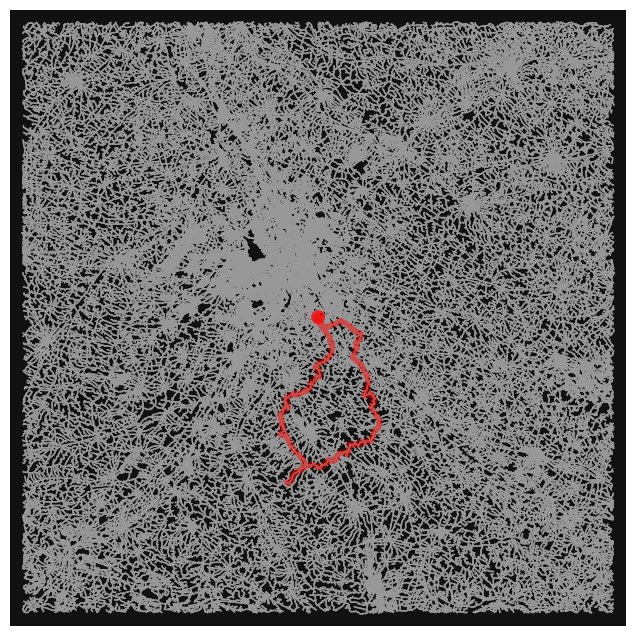

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [43]:
ox.plot_graph_route(G, Parcours, node_size=0)

In [42]:
print('La distance est de :', route_distance(G, Parcours), "km et le dénivelé est de : ", Denivele_parcours, "m")

La distance est de : 95.96 km et le dénivelé est de :  1125.1236572265625 m
